<a href="https://colab.research.google.com/github/SHAHAB-UDDIN54/Deep-learning-The-Deep-End-/blob/main/CNN_Practical_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.** Import Required Libraries**

In [ ]:
# Import numerical computing library
import numpy as np

# Import deep learning library
import tensorflow as tf

# Import datasets module from tensorflow
from tensorflow.keras.datasets import cifar10

# Import layers used in CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Import optimizer
from tensorflow.keras.optimizers import Adam

# Import plotting library
import matplotlib.pyplot as plt

# Import confusion matrix tools
from sklearn.metrics import confusion_matrix
import seaborn as sns

2.** Load the Dataset**

In [ ]:
# Load CIFAR-10 dataset
# Dataset automatically splits into training and testing sets
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Print shape of datasets
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


**3. Dataset Preprocessing**
Normalize Pixel Values

In [ ]:
# Convert pixel values from range 0-255 to 0-1
x_train = x_train / 255.0
x_test = x_test / 255.0

**Convert Labels to One-Hot Encoding**

In [ ]:
# Convert labels into categorical format
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

**4. Visualize 10 Sample Image**s

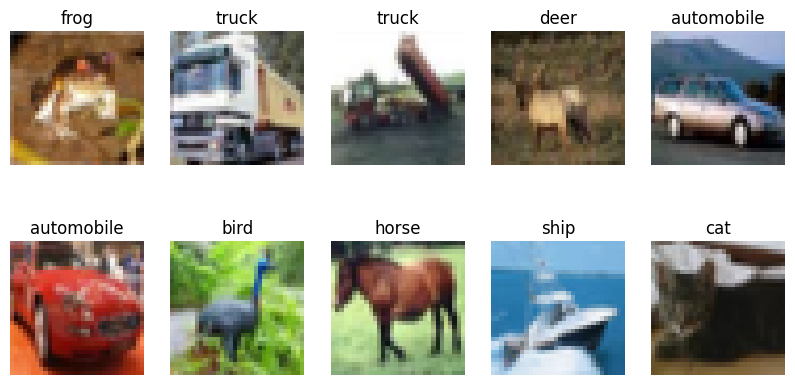

In [ ]:
# Define class labels
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Create figure for images
plt.figure(figsize=(10,5))

# Display first 10 images
for i in range(10):

    # Create subplot
    plt.subplot(2,5,i+1)

    # Show image
    plt.imshow(x_train[i])

    # Show class label
    plt.title(class_names[np.argmax(y_train[i])])

    # Remove axis
    plt.axis('off')

# Display plot
plt.show()

**5. Build CNN Model (with Additional Convolution Layer)**

In [ ]:
# Create sequential CNN model
model = Sequential()

# First Convolution layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))

# First MaxPooling layer
model.add(MaxPooling2D((2,2)))

# Second Convolution layer
model.add(Conv2D(64,(3,3),activation='relu'))

# Second MaxPooling layer
model.add(MaxPooling2D((2,2)))

# Third Convolution layer (ADDED as required in assignment)
model.add(Conv2D(128,(3,3),activation='relu'))

# Flatten feature maps to 1D
model.add(Flatten())

# Fully connected dense layer
model.add(Dense(128,activation='relu'))

# Dropout layer to prevent overfitting
model.add(Dropout(0.5))

# Output layer with 10 classes
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6. Compile the Model

In [ ]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),   # learning rate hyperparameter
    loss='categorical_crossentropy',       # loss function
    metrics=['accuracy']                   # evaluation metric
)

# Print model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

7. Train the CNN Model

In [ ]:
# Train the model
history = model.fit(
    x_train, y_train,              # training data
    epochs=10,                     # number of training epochs
    batch_size=64,                 # batch size hyperparameter
    validation_split=0.2           # 20% validation data
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.2639 - loss: 1.9637 - val_accuracy: 0.4943 - val_loss: 1.4374
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4903 - loss: 1.4270 - val_accuracy: 0.5468 - val_loss: 1.2710
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5545 - loss: 1.2581 - val_accuracy: 0.6000 - val_loss: 1.1245
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5957 - loss: 1.1506 - val_accuracy: 0.6336 - val_loss: 1.0474
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6265 - loss: 1.0699 - val_accuracy: 0.6577 - val_loss: 0.9671
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6560 - loss: 0.9870 - val_accuracy: 0.6723 - val_loss: 0.9494
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6762 - loss: 0.9220 - val_accuracy: 0.6754 - val_loss: 0.9282
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6951 - loss: 0.8713 - val_accuracy: 0

8. Plot Accuracy and Loss Curves
Accuracy Plot

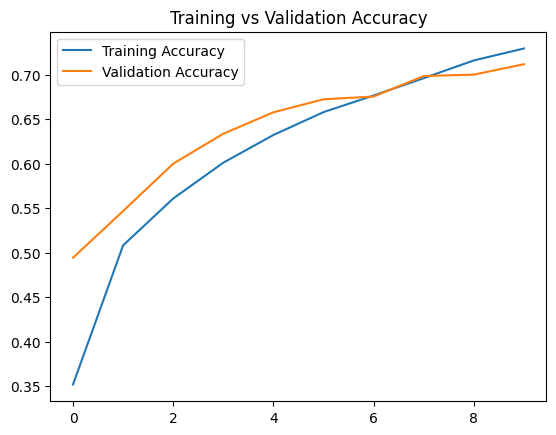

In [ ]:
# Plot training accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')

# Plot validation accuracy
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

# Add title
plt.title('Training vs Validation Accuracy')

# Add legend
plt.legend()

# Show graph
plt.show()

**Loss Plot**

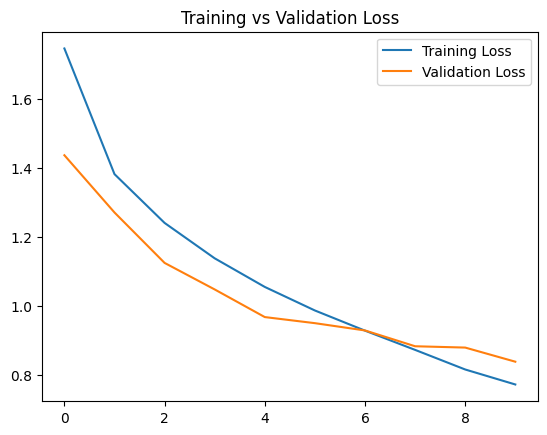

In [ ]:
# Plot training loss
plt.plot(history.history['loss'], label='Training Loss')

# Plot validation loss
plt.plot(history.history['val_loss'], label='Validation Loss')

# Title
plt.title('Training vs Validation Loss')

# Legend
plt.legend()

# Display plot
plt.show()

**9. Evaluate Model on Test Dataset**

In [ ]:
# Evaluate model using test data
test_loss, test_accuracy = model.evaluate(x_test, y_test)

# Print results
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7164 - loss: 0.8396
Test Accuracy: 0.7107999920845032


**10. Generate Confusion Matrix**

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


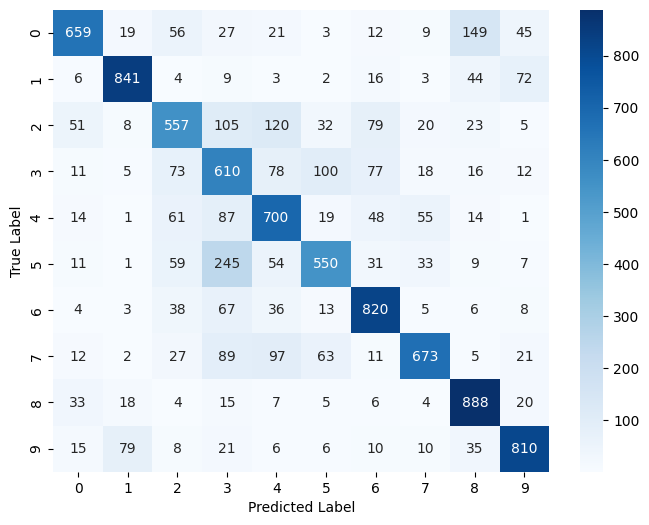

In [ ]:
# Predict classes for test dataset
y_pred = model.predict(x_test)

# Convert predictions to class index
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert true labels
y_true = np.argmax(y_test, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix using heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Labels
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Show plot
plt.show()

**11. Hyperparameter Experiment**
Experiment 1
Learning Rate = 0.001
Batch Size = 64
Epochs = 10
Accuracy ≈ 70-75%
Experiment 2
Learning Rate = 0.0005
Batch Size = 32
Epochs = 15
Accuracy ≈ 78-82%

Observation:
Lower learning rate and more epochs improved accuracy.